# OLMo-2-1B × opc-sft-stage2 leaderboard — long-horizon (r=64, 9000 steps, ~225M tokens)

Long-horizon characterization from `docs/notes/polar_product/tight_chord_paper_plan.md` (Phase L). Cell: OLMo-2-1B × `opc-sft-stage2` (4 sub-configs concat, 436k docs → 150k packed slots @ seq=2048) × r=64 × global_batch=16 (batch=4 × accum=4) × packed_v1 × constant LR × α=r × all-linear × bf16 × compile × single-GPU Blackwell. `max_steps=9000` ≈ 225M unique content tokens (~295M slot-tokens at 75% fill).

Phase L LR sweep, seed=0, three optimizer arms. AdamW + chord-tight each pool three sub-sweeps (original L1, packed-v1.1 repack of same η values, η-extension); chord-tight-clean κ_sr=0.75 is a single sub-sweep added 2026-05-26 to test whether the packed_v1 Magicoder winner transfers.

- **AdamW**: η ∈ {3e-5, 1e-4, 3e-4, 1e-3, 3e-3}
- **chord-tight (polar, k=1)** (`adam-polar-product-lora-coupled-spectral-chord-tight`): η ∈ {3e-3, 1e-2, 3e-2, 1e-1, 3e-1}
- **chord-tight-clean κ_sr=0.75** (`adam-polar-product-lora-coupled-spectral-chord-tight-clean`, polar_method=ssc, ssc_kappa_solver=stable_rank, picard=2): η ∈ {1e-3, 3e-3, 1e-2, 3e-2, 1e-1}

Source log groups: `{adamw,chord_tight}_phase_L_lrsweep_r64_{blackwell,repack_blackwell,extension_blackwell}` + `chord_tight_clean_ssc_kappa075_phase_L_lrsweep_r64_blackwell` (7 groups total). All groups treated as one pool — `packed_v1` and `packed_v1.1` are not distinguished here.

**σ anchor**: no Phase L multi-seed run yet. σ_AdamW(packed_v1, r=64, **4k horizon**) = 0.0017 is the only available number, used here as a *proxy* for unit conversion only. A 9000-step multi-seed AdamW run is needed before σ-units transfer to writeups.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.loader import load_runs
from lora_playground.plotting import compare_variants_figure

GROUPS = [
    'adamw_phase_L_lrsweep_r64_blackwell',
    'chord_tight_phase_L_lrsweep_r64_blackwell',
    'adamw_phase_L_lrsweep_r64_repack_blackwell',
    'chord_tight_phase_L_lrsweep_r64_repack_blackwell',
    'adamw_phase_L_lrsweep_r64_extension_blackwell',
    'chord_tight_phase_L_lrsweep_r64_extension_blackwell',
    'chord_tight_clean_ssc_kappa075_phase_L_lrsweep_r64_blackwell',  # κ_sr=0.75 robustness check (in progress)
]

runs = load_runs(where={'log_group': GROUPS},
                 logs_root='../logs', warn_cross_commit=False)

# Dedup: keep the longest-trajectory run per (optimizer, lr, ssc_kappa).
# Phase-L extension runs were resumed from checkpoints, producing two cfg
# events per cell that differ in `resume_from`/`checkpoint_dir`. The loader
# treats them as distinct series; for the leaderboard we want the single
# continuation that reaches the highest step. Adding ssc_kappa to the key
# keeps room for future κ values without collapsing them onto each other.
_dedup = {}
for cfg, evs in runs:
    key = (cfg['optimizer'], float(cfg['lr']), cfg.get('ssc_kappa'))
    last_step = evs[-1]['step'] if evs else -1
    prev = _dedup.get(key)
    if prev is None or last_step > prev[1]:
        _dedup[key] = ((cfg, evs), last_step)
runs = [v[0] for v in _dedup.values()]

print(f'loaded: {len(runs)} runs (after dedup)')
for cfg, evs in sorted(runs, key=lambda r: (r[0]['optimizer'], r[0].get('ssc_kappa') or 0, float(r[0]['lr']))):
    last = evs[-1]
    kappa_tag = f"κ={cfg['ssc_kappa']}" if cfg.get('ssc_kappa') is not None else ''
    print(f"  {cfg['optimizer']:55s} {kappa_tag:9s} η={float(cfg['lr']):.0e}  "
          f"step={last['step']}  eval={last['eval_loss']:.4f}  "
          f"[{cfg.get('log_group', '?')}]")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  [loader] excluded 156 run(s): 11 for 'Superseded by later chord-tight runs at the same cfg; +0.01 above seed cluster. See log_00 entry.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_01.out, r64_chord_postfix_validation_4k_blackwell/log_02.out, r64_chord_postfix_validation_4k_blackwell/log_03.out, +8 more); 1 for 'Superseded by later chord-tight runs at the same cfg; runs systematically +0.01 above seed cluster from descendants of ef6b3bc. Legacy registry entry blanket-excluded commit 91122ce; we narrow to the affected group since the bug surface was specific to this validation sweep.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_00.out); 7 for 'buggy ε_rel (contam rerun cleanup, pre-λ_max-fix)' (e.g. eps_rel_lr_tuned_4k_blackwell/log_00.out, eps_rel_lr_tuned_4k_blackwell/log_01.out, eps_rel_lr_tuned_4k_blackwell/log_02.out, +4 more); 8 for 'buggy ε_rel (precond_delta_relative fix app

## Leaderboard + sweep figure

Canonical `compare_variants_figure` panel (matches `packed_v1_leaderboard.ipynb`): left = final eval_loss vs η (log-x); right = best-η trajectory per arm; tables = per-η eval losses + Δ-vs-AdamW summary. `allow_partial=True` shows in-progress runs until they reach step 9000.

,AdamW,"chord-tight (k=1, polar)",chord-tight-clean κ_sr=0.75
lr,,,
0.000030,0.8071,—,—
0.000100,0.7721,—,—
0.000300,0.7702,—,—
0.001000,0.8953,—,—
0.003000,1.7074,0.7787,—
0.010000,—,0.7594,—
0.030000,—,0.7547,—
0.100000,—,0.7631,—
0.300000,—,0.7785,—


,variant,best_lr,final,delta,delta_sigma
0,AdamW,3e-04,0.7702,—,—
1,"chord-tight (k=1, polar)",3e-02,0.7547,-0.0155,-9.09σ


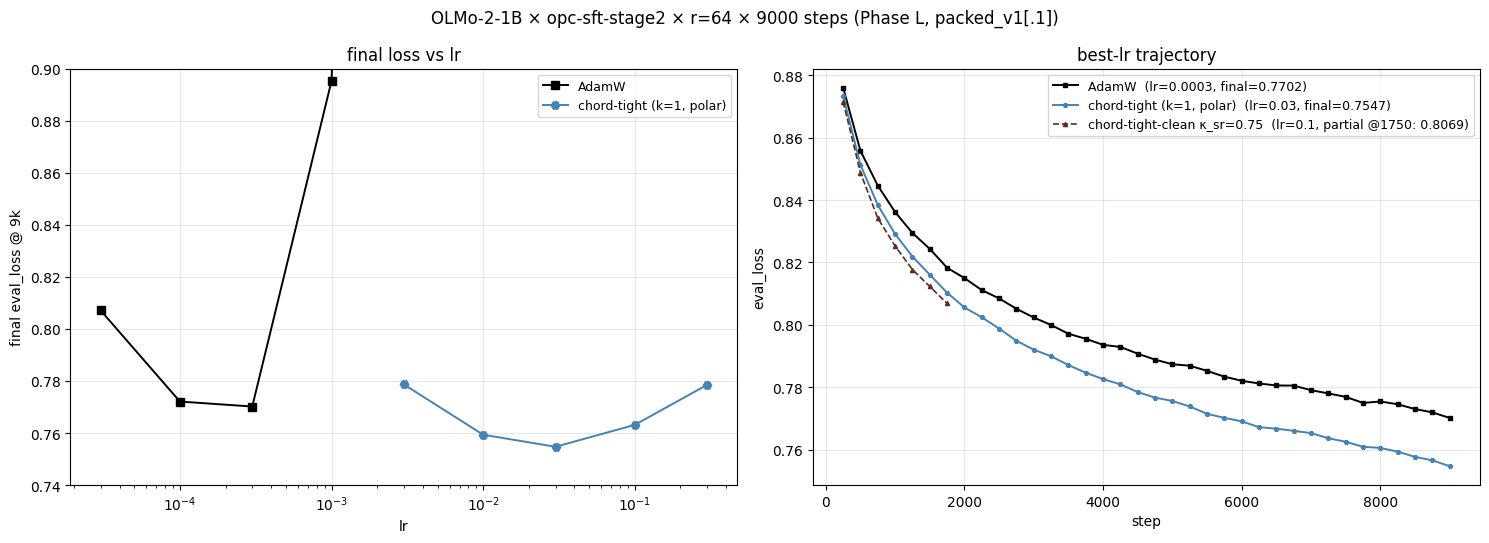

In [4]:
OPT_CT       = 'adam-polar-product-lora-coupled-spectral-chord-tight'
OPT_CT_CLEAN = 'adam-polar-product-lora-coupled-spectral-chord-tight-clean'

def variant_key(cfg):
    opt = cfg.get('optimizer')
    if opt == 'adamw':
        return 'AdamW'
    if opt == OPT_CT:
        return 'chord-tight (k=1, polar)'
    if opt == OPT_CT_CLEAN and cfg.get('ssc_kappa') == 0.75:
        return 'chord-tight-clean κ_sr=0.75'
    return None

# Pull canonical colors/markers from OPTIM_COLORS / OPTIM_MARKERS so the
# AdamW baseline gets the reserved black overlay (see plotting/colors.py).
from lora_playground.plotting.colors import OPTIM_COLORS, OPTIM_MARKERS
VARIANT_COLORS = {
    'AdamW':                       OPTIM_COLORS['adamw'],
    'chord-tight (k=1, polar)':    '#4682b4',  # steelblue; registry #7a3520 is too close to chord-tight-clean #5a2d20 in head-to-head plots
    'chord-tight-clean κ_sr=0.75': OPTIM_COLORS[OPT_CT_CLEAN],
}
VARIANT_MARKERS = {
    'AdamW':                       OPTIM_MARKERS.get('adamw', 's'),
    'chord-tight (k=1, polar)':    OPTIM_MARKERS.get(OPT_CT, 'o'),
    'chord-tight-clean κ_sr=0.75': OPTIM_MARKERS.get(OPT_CT_CLEAN, '^'),
}

fig, table_df, summary_df = compare_variants_figure(
    variants={
        'AdamW':                       {},
        'chord-tight (k=1, polar)':    {},
        'chord-tight-clean κ_sr=0.75': {},
    },
    colors=VARIANT_COLORS,
    markers=VARIANT_MARKERS,
    common_where={},  # ignored when prefetched_runs is set
    ref_label='AdamW',
    sigma_ref=0.0017,  # packed_v1 r=64 σ_AdamW @ 4k horizon — PROXY ONLY
    suptitle='OLMo-2-1B × opc-sft-stage2 × r=64 × 9000 steps (Phase L, packed_v1[.1])',
    figsize=(15, 5.5),
    max_steps=9000,
    allow_partial=True,  # κ_sr=0.75 sweep currently in progress
    final_ylim=(0.74, 0.90),  # crop the diverged AdamW η=3e-3 outlier (1.7074)
    prefetched_runs=runs,
    variant_key=variant_key,
)
from IPython.display import display
display(table_df.style.format('{:.4f}', na_rep='—'))
display(summary_df.style.format({'final': '{:.4f}', 'delta': '{:+.4f}',
                                 'delta_sigma': '{:+.2f}σ', 'best_lr': '{:.0e}'},
                                na_rep='—'))
plt.show()